# Word Embedding
**Word Embedding**은 단어를 고정된 차원의 벡터로 변환하는 기술로, 단어 간의 의미적 유사성을 반영하도록 학습된 벡터를 말한다.  

이 기술은 자연어 처리에서 문장을 처리하고 이해하는 데 활용된다.  

숫자로 표현된 단어 목록을 통해 감정을 추출하는 것도 가능하다.  

연관성 있는 단어들을 군집화하여 다차원 공간에 벡터로 나타낼 수 있으며, 이는 단어나 문장을 벡터 공간에 매핑하는 과정이다.  


**Embedding Matrix 예시**

*아래 표의 벡터 값들은 모두 기계 학습을 통해 학습된 결과이다.*  

| Dimension | Man (5391) | Woman (9853) | King (4914) | Queen (7157) | Apple (456) | Orange (6257) |
|-----------|------------|--------------|-------------|--------------|-------------|---------------|
| 성별      | -1         | 1            | -0.95       | 0.97         | 0.00        | 0.01          |
| 귀족      | 0.01       | 0.02         | 0.93        | 0.95         | -0.01       | 0.00          |
| 나이      | 0.03       | 0.02         | 0.7         | 0.69         | 0.03        | -0.02         |
| 음식      | 0.04       | 0.01         | 0.02        | 0.01         | 0.95        | 0.97          |

<br>

*아래는 전치된 표이다.*

| Word          | 성별   | 귀족   | 나이   | 음식   |
|---------------|--------|--------|--------|--------|
| Man (5391)    | -1.00  | 0.01   | 0.03   | 0.04   |
| Woman (9853)  | 1.00   | 0.02   | 0.02   | 0.01   |
| King (4914)   | -0.95  | 0.93   | 0.70   | 0.02   |
| Queen (7157)  | 0.97   | 0.95   | 0.69   | 0.01   |
| Apple (456)   | 0.00   | -0.01  | 0.03   | 0.95   |
| Orange (6257) | 0.01   | 0.00   | -0.02  | 0.97   |

- **의미적 유사성 반영**  
  - 단어를 고정된 크기의 실수 벡터로 표현하며, 비슷한 의미를 가진 단어는 벡터 공간에서 가깝게 위치한다.  
  - 예를 들어, "king"과 "queen"은 비슷한 맥락에서 자주 사용되므로 벡터 공간에서 가까운 위치에 배치된다.  

- **밀집 벡터(Dense Vector)**  
  - BoW, DTM, TF-IDF와 달리 Word Embedding은 저차원 밀집 벡터로 변환되며, 차원이 낮으면서도 의미적으로 풍부한 정보를 담는다.  
  - 벡터 차원은 보통 100 또는 300 정도로 제한된다.  

- **문맥 정보 반영**  
  - Word Embedding은 단어 주변의 단어들을 학습해 단어의 의미를 추론한다.  
  - 예를 들어, "bank"라는 단어가 "river"와 함께 나오면 "강둑"을, "money"와 함께 나오면 "은행"을 의미한다고 학습한다.  

- **학습 기반 벡터**  
  - Word Embedding은 대규모 텍스트 데이터에서 단어 간 연관성을 학습해 벡터를 생성한다.  
  - 반면, BoW나 TF-IDF는 단순한 규칙 기반 벡터화 방법이다.  

## Word2Vec
[딥 러닝을 이용한 자연어 처리 입문 - 09-02 워드투벡터(Word2Vec)](https://wikidocs.net/22660)


- 2013년 구글에서 개발한 Word Embedding 방법
- One-hidden layer 의 shallow network
- 최초의 neural embedding model
- 매우 큰 corpus(10억, 100억 단어)에서 자동학습
    - 비지도 지도학습(자기 지도학습)이라 할 수 있다.
    - 많은 데이터를 기반으로 label값을 유추하고 이를 지도학습에 사용했다.
- 예시: 다음 문장에서 이사금의 뜻을 모르지만, 주변단어로부터 *왕*과 비슷한 맥락의 단어일것이라 유추할 수 있다. 이를 반영해 벡터스페이스상에 가깝게 위치하게 된다.
    - **이사금**께 충성을 맹세하였다.
    - **왕**께 충성을 맹세하였다.
    

**WordVec 훈련방식에 따른 구분**
1. `CBOW` 주변단어로 중심단어를 예측
2. `Skip-gram` 중심단어로 주변단어를 예측


### CBOW (Continuous Bag of Words)  
CBOW는 원-핫 벡터를 사용하지만, 이는 단순히 위치를 가리킬 뿐 vocabulary를 직접적으로 참조하지 않는다.  

**예시:**  

> The fat cat sat on the mat  

주어진 문장에서 'sat'이라는 단어를 예측하는 것이 CBOW의 주요 작업이다.  
- **중심 단어(center word):** 예측하려는 단어 ('sat')  
- **주변 단어(context word):** 예측에 사용되는 단어들  

중심 단어를 예측하기 위해 앞뒤 몇 개의 단어를 참고할지 결정하는 범위를 **윈도우(window)** 라고 한다.  
예를 들어, 윈도우 크기가 2이고 중심 단어가 'sat'라면, 앞의 두 단어(fat, cat)와 뒤의 두 단어(on, the)를 입력으로 사용한다.  
윈도우 크기가 n일 경우, 참고하는 주변 단어의 개수는 총 2n이다. 윈도우를 옆으로 이동하며 학습 데이터를 생성하는 방법을 **슬라이딩 윈도우(sliding window)** 라고 한다.  

![](https://static.wikidocs.net/images/page/22660/%EB%8B%A8%EC%96%B4.PNG)


**훈련 과정**

CBOW는 embedding 벡터를 학습하기 위한 구조를 갖는다. 초기에는 가중치가 임의의 값으로 설정되며, 역전파를 통해 최적화된다.  

![](https://static.wikidocs.net/images/page/22660/word2vec_renew_1.PNG)

Word2Vec은 은닉층이 하나뿐인 얕은 신경망(shallow neural network) 구조를 사용한다.  
학습 대상이 되는 주요 가중치는 두 가지이다:  

1. **투사층(projection layer):**  
   - 활성화 함수가 없으며 룩업 테이블 연산을 담당한다.  
   - 입력층과 투사층 사이의 가중치 W는 V × M 행렬로 표현되며, 여기서 **V는 단어 집합의 크기, M은 벡터의 차원**이다.  
   - W 행렬의 각 행은 학습 후 단어의 M차원 임베딩 벡터로 간주된다.  
   - 예를 들어, 벡터 차원을 5로 설정하면 각 단어의 임베딩 벡터는 5차원이 된다.  

2. **출력층:**  
   - 투사층과 출력층 사이의 가중치 W'는 M × V 행렬로 표현된다.  
   - 이 두 행렬(W와 W')은 서로 독립적이며, 학습 전에는 랜덤 값으로 초기화된다.  

![](https://static.wikidocs.net/images/page/22660/word2vec_renew_2.PNG)


**예측 과정**
1. CBOW는 계산된 룩업 테이블의 평균을 구한 뒤, 출력층의 가중치 W'와 내적한다.  
2. 결과값은 **소프트맥스(softmax)** 활성화 함수에 입력되어, 중심 단어일 확률을 나타내는 예측값으로 변환된다.  
3. 출력된 예측값(스코어 벡터)은 실제 타겟 원-핫 벡터와 비교되며, **크로스 엔트로피(cross-entropy)** 함수로 손실값을 계산한다.  

![](https://static.wikidocs.net/images/page/22660/word2vec_renew_3.PNG)

![](https://static.wikidocs.net/images/page/22660/word2vec_renew_5.PNG)

손실 함수 식:  
$
cost(\hat{y}, y) = -\sum_{j=1}^{V} y_{j} \cdot log(\hat{y}_{j})
$  

여기서, $\hat{y}_{j}$는 예측 확률, $y_{j}$는 실제 값이며, V는 단어 집합의 크기를 의미한다.  


**학습 결과**  

역전파를 통해 가중치 W와 W'가 학습된다. 학습이 완료되면 W 행렬의 각 행을 단어의 임베딩 벡터로 사용하거나, W와 W' 모두를 이용해 임베딩 벡터를 생성할 수 있다.  

CBOW는 주변 단어를 기반으로 중심 단어를 예측하는 구조를 갖추고 있으며, 이를 통해 단어 간 의미적 관계를 효과적으로 학습할 수 있다.  


### Skip-gram
Skip-gram은 중심 단어에서 주변 단어를 예측한다. 윈도우 크기가 2일 때, 데이터셋은 다음과 같이 구성된다.

![](https://static.wikidocs.net/images/page/22660/skipgram_dataset.PNG)

![](https://static.wikidocs.net/images/page/22660/word2vec_renew_6.PNG)

중심 단어에 대해서 주변 단어를 예측하므로 투사층에서 벡터들의 평균을 구하는 과정은 없다.

여러 논문에서 성능 비교를 진행했을 때 전반적으로 Skip-gram이 CBOW보다 성능이 좋다고 알려져 있다.

In [1]:
%pip install lxml gensim

Note: you may need to restart the kernel to use updated packages.


In [2]:
from lxml import etree

xml = open('ted_en.xml','r',encoding='UTF-8')

# XML 문서를 파싱해서 tree 구조로 읽어온다.
tree = etree.parse(xml)

# XML 문서 안에서 <content> 태그의 텍스트만 출력한다.
content = tree.xpath("//content/text()")
print(len(content))

# 리스트에 담긴 여러 문자열을 하나의 긴 문자열로 합친다.
corpus = '\n'.join(content)

print(corpus[:500])

2085
Here are two reasons companies fail: they only do more of the same, or they only do what's new.
To me the real, real solution to quality growth is figuring out the balance between two activities: exploration and exploitation. Both are necessary, but it can be too much of a good thing.
Consider Facit. I'm actually old enough to remember them. Facit was a fantastic company. They were born deep in the Swedish forest, and they made the best mechanical calculators in the world. Everybody used them. A


In [3]:
# 데이터 정제
import re

# 무대 지시문이 있는지 확인
print(re.search(r"\((Laughter|Applause)\)",corpus))

# 영문자/숫자/공백 이외의 특수 문자가 있는지 확인
print(re.search(r'[^a-z0-9]+',corpus,re.IGNORECASE))

# 대문자가 있는지 확인
print(re.search(r'[A-Z]+',corpus))


<re.Match object; span=(866, 876), match='(Laughter)'>
<re.Match object; span=(4, 5), match=' '>
<re.Match object; span=(0, 1), match='H'>


In [4]:
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize

# 괄호 안 텍스트 제거
corpus = re.sub(r'\([^)]*\)','',corpus)

# 불필요한 특수문자 제거
corpus = re.sub(r'[^a-z0-9\s.,!?]+','',corpus,flags=re.IGNORECASE)
# 소문자 변환
corpus = corpus.lower()

# 불용어 제거
en_stopwords = stopwords.words('english')

sentences = sent_tokenize(corpus)

normalized_sentences = []

for sent in sentences:
    tokens = word_tokenize(sent)
    normalized_tokens = [token for token in  tokens if token not in en_stopwords]
    normalized_sentences.append(normalized_tokens)

print('총 문장 수 :', len(normalized_sentences))

총 문장 수 : 271088


In [5]:
# 전처리 결과 샘플 확인
for sent in normalized_sentences[:3]:
    print(sent)

['two', 'reasons', 'companies', 'fail', ',', 'whats', 'new', '.']
['real', ',', 'real', 'solution', 'quality', 'growth', 'figuring', 'balance', 'two', 'activities', 'exploration', 'exploitation', '.']
['necessary', ',', 'much', 'good', 'thing', '.']


## word2vec 학습

In [6]:
from gensim.models.word2vec import Word2Vec

model = Word2Vec(
    sentences=normalized_sentences,
    vector_size=5,          # 단어를 몇 차원 벡터로 표현할지
    window=5,               # 중심 단어 기준 앞뒤 몇 개 단어를 문맥으로 볼지
    min_count=5,            # 최소 5번 이상 등장한 단어만 학습에 포함
    workers=4,              # 병렬 처리에 사용할 CPU 코어 수
    sg=0                    # 0 : CBOW, 1 : SKIP-GRAM
)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [7]:
# 학습된 임베딩 벡터 행렬 크기 확인
model.wv.vectors.shape

(22174, 5)

In [8]:
# 단어 사전 확인
list(model.wv.key_to_index.keys())[:30]

[',',
 '.',
 '?',
 'one',
 'people',
 'like',
 'know',
 'going',
 'think',
 'thats',
 'see',
 'would',
 'really',
 'get',
 'im',
 'us',
 'time',
 'world',
 'dont',
 'actually',
 'way',
 'well',
 'years',
 'things',
 'could',
 'go',
 'want',
 'make',
 'right',
 'said']

In [9]:
import pandas as pd

embed_df = pd.DataFrame(
    model.wv.vectors,
    index=model.wv.key_to_index.keys()
)

embed_df.head(20)

,0,1,2,3,4
",",0.889951,1.105471,1.147010,-0.594168,-0.749320
.,0.080723,1.755232,0.853950,-1.050784,-0.156020
?,0.985587,0.863838,1.805611,-1.957626,0.086231
one,1.953601,1.317172,0.938279,-0.149090,-0.612700
people,2.825284,1.795456,3.069240,1.174921,2.668913
like,0.662045,0.998904,0.798459,-2.720568,-1.039108
know,1.650241,-0.053928,3.068366,-1.617943,0.110294
going,2.242319,1.540257,1.393421,-3.076248,0.959322
think,0.139097,0.304111,4.112939,-1.514910,1.355499
thats,-0.445726,0.503657,2.248291,-1.166149,-0.729754


In [10]:
#  단어간 유사도 검사
print(model.wv.most_similar('man'))
print(model.wv.similarity('man','woman'))

[('friend', 0.9902775287628174), ('woman', 0.9862932562828064), ('mine', 0.9818478226661682), ('son', 0.9814807772636414), ('shes', 0.9806938171386719), ('party', 0.9802672266960144), ('name', 0.9774033427238464), ('hes', 0.9758927226066589), ('david', 0.9743778705596924), ('book', 0.9719337821006775)]
0.98629326


In [11]:
# 임베딩 벡터 저장
model.wv.save_word2vec_format('eng_w2v')

In [12]:
# 임베딩 벡터 로드
from gensim.models import KeyedVectors

model_wv = KeyedVectors.load_word2vec_format('eng_w2v')

## 한국어 word2vec
https://github.com/e9t/nsmc

In [13]:
import pandas as pd

ratings_df = pd.read_table('ratings.txt')
print(len(ratings_df))
ratings_df.tail()

200000


,id,document,label
199995,8963373,포켓 몬스터 짜가 ㅡㅡ;;,0
199996,3302770,쓰.레.기,0
199997,5458175,완전 사이코영화. 마지막은 더욱더 이 영화의질을 떨어트린다.,0
199998,6908648,왜난 재미없었지 ㅠㅠ 라따뚜이 보고나서 스머프 봐서 그런가 ㅋㅋ,0
199999,8548411,포풍저그가나가신다영차영차영차,0


In [14]:
# 결측치 확인
print(ratings_df.isnull().sum())

# 결측치 제거
ratings_df = ratings_df.dropna(how='any')
print(ratings_df.isnull().sum())

id          0
document    8
label       0
dtype: int64
id          0
document    0
label       0
dtype: int64


In [15]:
# 데이터 전처리
# document 컬럼에서 한글, 자모, 공백, 영숫자/밑줄 만 남기고 나머지 특수 문자 제거
ratings_df.loc[:,'document'] = ratings_df['document'].replace(
    r'[^가-힝ㄱ-ㅎㅏ-ㅣ\s\w]','',regex=True
)

ratings_df.head()

,id,document,label
0,8112052,어릴때보고 지금다시봐도 재밌어요ㅋㅋ,1
1,8132799,디자인을 배우는 학생으로 외국디자이너와 그들이 일군 전통을 통해 발전해가는 문화산업...,1
2,4655635,폴리스스토리 시리즈는 1부터 뉴까지 버릴께 하나도 없음 최고,1
3,9251303,와 연기가 진짜 개쩔구나 지루할거라고 생각했는데 몰입해서 봤다 그래 이런게 진짜 영화지,1
4,10067386,안개 자욱한 밤하늘에 떠 있는 초승달 같은 영화,1


In [16]:
# 불용어 처리 및 토큰화
from konlpy.tag import Okt
from tqdm import tqdm       # 반복문의 진행 상황 막대 그래프로 표현

stopwords = set('의 가 이 은 들 는 좀 잘 강 과 도 를 으로 자 에 와 한 하다'.split())

okt= Okt()

sentences = []

for sent in tqdm(ratings_df['document']):
    tokens = okt.morphs(sent,stem=True)
    tokens = [token for token in tokens if token not in stopwords]
    sentences.append(tokens)

# 전처리 결과 샘플 확인
print(sentences[:3])

100%|██████████| 199992/199992 [07:57<00:00, 418.59it/s]

[['어리다', '때', '보고', '지금', '다시', '보다', '재밌다', 'ㅋㅋ'], ['디자인', '을', '배우다', '학생', '외국', '디자이너', '그', '일군', '전통', '을', '통해', '발전', '문화', '산업', '부럽다', '사실', '우리나라', '에서도', '그', '어렵다', '시절', '끝', '까지', '열정', '을', '지키다', '노라노', '같다', '전통', '있다', '저', '같다', '사람', '꿈', '을', '꾸다', '이루다', '나가다', '수', '있다', '것', '감사하다'], ['폴리스스토리', '시리즈', '1', '부터', '뉴', '까지', '버리다', '하나', '없다', '최고']]


최대 길이 :  72
평균 길이 :  10.95749329973199


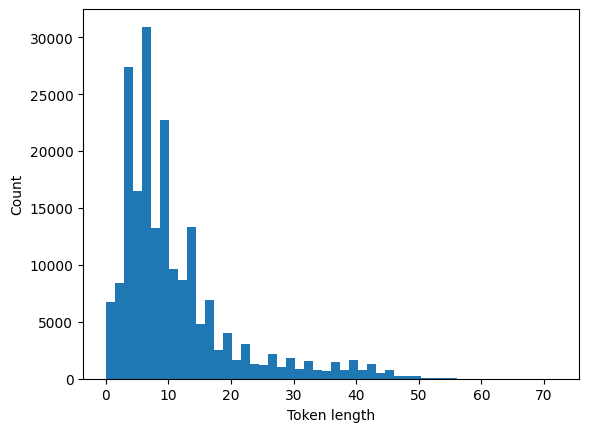

In [17]:
# 리뷰 같이 확인
import numpy as np
import matplotlib.pyplot as plt

# 각 리뷰(토큰 리스트)의 길이 계산
sent_len = [len(sent) for sent in sentences]

print('최대 길이 : ',max(sent_len))
print('평균 길이 : ',np.mean(sent_len))

# 길이 분포
plt.hist(sent_len,bins=50)
plt.xlabel('Token length')
plt.ylabel('Count')
plt.show()

In [18]:
# 한국어 word2vec 생성
from gensim.models.word2vec import Word2Vec

ko_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1            # SKIP-GRAM 방식
)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [19]:
# 임베딩 벡터 크기 확인
print(ko_model.wv.vectors.shape)

# 단어 사전 확인
for i, (word,index) in enumerate(ko_model.wv.key_to_index.items()):
    print(f'{word} : {index}')
    if i > 20 : break

(17209, 100)
영화 : 0
보다 : 1
을 : 2
없다 : 3
이다 : 4
있다 : 5
좋다 : 6
너무 : 7
다 : 8
정말 : 9
재밌다 : 10
되다 : 11
적 : 12
만 : 13
진짜 : 14
같다 : 15
점 : 16
로 : 17
아니다 : 18
않다 : 19
에서 : 20
만들다 : 21


In [20]:
# 유사도 검색
print('최민식 : ',ko_model.wv.most_similar('최민식'))
print('연기 : ',ko_model.wv.most_similar('연기'))
print('감동 : ',ko_model.wv.most_similar('감동'))


최민식 :  [('한석규', 0.8583254218101501), ('김명민', 0.819595992565155), ('안성기', 0.8176406621932983), ('최민수', 0.8070161938667297), ('채민서', 0.8019450306892395), ('설경구', 0.8014010787010193), ('최수종', 0.800410270690918), ('김창완', 0.7981677055358887), ('서영희', 0.7980865836143494), ('문소리', 0.7954242825508118)]
연기 :  [('연기력', 0.844188392162323), ('발연기', 0.803385317325592), ('미스캐스팅', 0.7274138927459717), ('조진웅', 0.7006757855415344), ('문소리', 0.6927735209465027), ('류승룡', 0.6823140382766724), ('중견', 0.6750211715698242), ('유해진', 0.6743539571762085), ('명연기', 0.6719790697097778), ('액션연기', 0.6695595979690552)]
감동 :  [('교훈', 0.7227988839149475), ('울림', 0.7124486565589905), ('물결', 0.6657477021217346), ('감격', 0.6522712111473083), ('지스토리', 0.6462879180908203), ('막막하다', 0.6408252120018005), ('찡하다', 0.6355369091033936), ('지게', 0.6332664489746094), ('자아내다', 0.6300802230834961), ('구애', 0.6283255219459534)]


In [21]:
# 저장
ko_model.wv.save_word2vec_format('kor_nsmc_w2v')

In [22]:
# 로드
from gensim.models import KeyedVectors
ko_model_wv = KeyedVectors.load_word2vec_format('kor_nsmc_w2v')

## embedding vector 시각화
https://ronxin.github.io/wevi/

https://word2vec.kr/search/

https://projector.tensorflow.org/

In [23]:
# tensor.tsv, metadata.tsv
!python -m gensim.scripts.word2vec2tensor --input kor_nsmc_w2v --output kor_nsmc_w2v

2026-04-23 11:24:03,439 - word2vec2tensor - INFO - running c:\Users\Playdata\AppData\Local\miniforge3\envs\dl_nlp_env\Lib\site-packages\gensim\scripts\word2vec2tensor.py --input kor_nsmc_w2v --output kor_nsmc_w2v
2026-04-23 11:24:03,439 - keyedvectors - INFO - loading projection weights from kor_nsmc_w2v
2026-04-23 11:24:05,239 - utils - INFO - KeyedVectors lifecycle event {'msg': 'loaded (17209, 100) matrix of type float32 from kor_nsmc_w2v', 'binary': False, 'encoding': 'utf8', 'datetime': '2026-04-23T11:24:05.195448', 'gensim': '4.4.0', 'python': '3.12.13 | packaged by conda-forge | (main, Mar  5 2026, 16:36:12) [MSC v.1944 64 bit (AMD64)]', 'platform': 'Windows-11-10.0.26200-SP0', 'event': 'load_word2vec_format'}
2026-04-23 11:24:06,008 - word2vec2tensor - INFO - 2D tensor file saved to kor_nsmc_w2v_tensor.tsv
2026-04-23 11:24:06,008 - word2vec2tensor - INFO - Tensor metadata file saved to kor_nsmc_w2v_metadata.tsv
2026-04-23 11:24:06,008 - word2vec2tensor - INFO - finished running